170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 45s 0us/step
Train: (50000, 32, 32, 3)
Test:  (10000, 32, 32, 3)
Piksel aralığı: 0 - 255


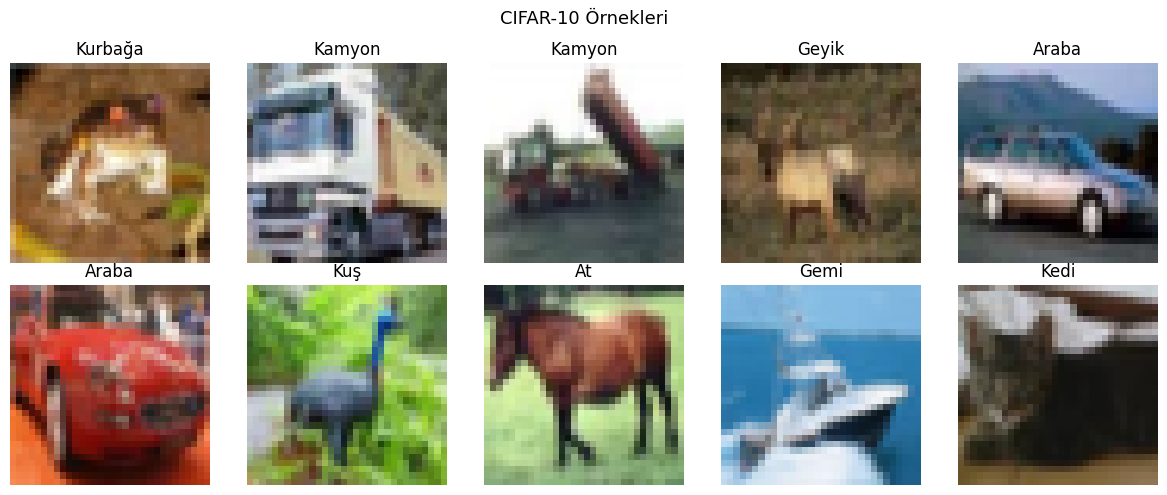

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# CIFAR-10 Keras'ın içinde geliyor — indirmeye gerek yok
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Sınıf isimleri
class_names = ['Uçak', 'Araba', 'Kuş', 'Kedi', 'Geyik',
               'Köpek', 'Kurbağa', 'At', 'Gemi', 'Kamyon']

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Piksel aralığı: {X_train.min()} - {X_train.max()}")

# Birkaç görüntü göster
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i])
    ax.set_title(class_names[y_train[i][0]])
    ax.axis('off')
plt.suptitle("CIFAR-10 Örnekleri", fontsize=13)
plt.tight_layout()
plt.show()

In [2]:
# Normalizasyon
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# One-hot
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  10)

print(f"Shape: {X_train.shape}")  # (50000, 32, 32, 3) — 3 kanal RGB

Shape: (50000, 32, 32, 3)


In [3]:
# CIFAR-10 için MLP
# 32x32x3 = 3072 düz sayı
X_train_flat = X_train.reshape(-1, 3072)
X_test_flat  = X_test.reshape(-1, 3072)

mlp_cifar = keras.Sequential([
    keras.layers.Dense(256, activation='relu', input_shape=(3072,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64,  activation='relu'),
    keras.layers.Dense(10,  activation='softmax')
])

mlp_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_cifar.summary()

c:\Python\Python3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 828,490 (3.16 MB)

 Trainable params: 828,490 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ── 1. CIFAR-10 MLP Eğitimi ───────────────────────────────
history_mlp_cifar = mlp_cifar.fit(
    X_train_flat, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.3114 - loss: 1.8997 - val_accuracy: 0.3678 - val_loss: 1.7525
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3916 - loss: 1.6977 - val_accuracy: 0.4122 - val_loss: 1.6552
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4186 - loss: 1.6211 - val_accuracy: 0.4310 - val_loss: 1.5852
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4407 - loss: 1.5659 - val_accuracy: 0.4248 - val_loss: 1.6014
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4519 - loss: 1.5273 - val_accuracy: 0.4446 - val_loss: 1.5432
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4665 - loss: 1.4919 - val_accuracy: 0.4332 - val_loss: 1.5818
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4752 - loss: 1.4683 - val_accuracy: 0.4612 - val_loss: 1.4961
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.4884 - loss: 1.4385 - val_accuracy: 0.

In [5]:
test_loss_mlp, test_acc_mlp = mlp_cifar.evaluate(X_test_flat, y_test_oh, verbose=0)
print(f"CIFAR-10 MLP Test Accuracy: {test_acc_mlp:.4f}")


CIFAR-10 MLP Test Accuracy: 0.5036


In [6]:
# ── 2. CIFAR-10 Basit CNN ─────────────────────────────────
cnn_cifar = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

cnn_cifar.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_cifar.summary()

history_cnn_cifar = cnn_cifar.fit(
    X_train, y_train_oh,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)



c:\Python\Python3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.3929 - loss: 1.6533 - val_accuracy: 0.5328 - val_loss: 1.2910
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.5496 - loss: 1.2632 - val_accuracy: 0.6362 - val_loss: 1.0371
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.6200 - loss: 1.0818 - val_accuracy: 0.6794 - val_loss: 0.9182
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.6632 - loss: 0.9582 - val_accuracy: 0.6926 - val_loss: 0.8897
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.6930 - loss: 0.8761 - val_accuracy: 0.7184 - val_loss: 0.8011
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7191 - loss: 0.8062 - val_accuracy: 0.7364 - val_loss: 0.7593
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7408 - loss: 0.7457 - val_accuracy: 0.7470 - val_loss: 0.7501
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 32ms/step - accuracy: 0.7557 - loss: 0.6958 - 

In [7]:
test_loss_cnn, test_acc_cnn = cnn_cifar.evaluate(X_test, y_test_oh, verbose=0)
print(f"CIFAR-10 CNN Test Accuracy: {test_acc_cnn:.4f}")

CIFAR-10 CNN Test Accuracy: 0.7542
